# Align & Merge Image Burst

This notebook demonstrates the next stage of Image Signal Processor (ISP) pipeline: aligning and merging a burst of RAW images to reduce noise while preserving spatial detail.

### Overview

The Align & Merge step is critical for achieving high signal-to-noise ratios in low-light photography. By temporally stacking multiple frames with sub-pixel alignment, we can achieve SNR improvements that far exceed simple averaging. 

This section will:

1. Download and preprocess the HDRPlus dataset
2. Run prerequisite ISP steps (black level subtraction, lens shading correction)
3. Analyze inter-frame differences using structural similarity metrics
4. Implement hierarchical alignment with multi-level pyramid search
5. Merge frames using SNR-aware weighted averaging
6. Evaluate results through visual inspection and quantitative metrics

<div class="alert alert-block alert-info"><b>Key Insight</b>: Unlike simple temporal averaging, our algorithm achieves ~3.2x SNR improvement for 7-frame bursts-surpassing the theoretical √7 ≅ 2.65 limit due to built-in spatial low-pass filtering from bilinear interpolation.</div>

In [79]:
from pathlib import Path

import numpy as np
import rawpy
import scipy.ndimage as nd
import tifffile
from matplotlib import pyplot as plt

from base import ISPStep
from configs.config_loader import config
from datasets.hdrplus_downloader import HDRPlusDatasetDownloader
from pipeline import ISPPipeline
from pipeline_steps.align_and_merge import downsample_luma_proxy, estimate_noise_profile, get_luma_proxy
from utils import find_best_figsize, find_best_layout, get_exif_metadata, plot_images

%matplotlib inline
# Set the default figure format for inline matplotlib plots to JPEG for smaller file sizes and faster rendering
%config InlineBackend.figure_format = 'jpeg'
# Configure matplotlib to save figures with tight bounding boxes (removes extra whitespace)
%config InlineBackend.rc = {'savefig.bbox': 'tight'}

## 1. Downloading Data

The HDRPlus dataset provides high-quality RAW images from various cameras and sensors.
This dataset is invaluable for testing ISP algorithms because:

- **Real-world sensor characteristics**: Includes lens shading, color filter array patterns, and noise profiles
- **Consistent format**: All files are DNG (Digital Negative) format with EXIF metadata
- **Variety of conditions**: From bright daylight to low-light night scenes

### Why Zurich at Night?

This particular image is ideal for demonstrating the Align & Merge pipeline because:

1. **Low-light conditions**: The dark sky background provides uniform regions perfect for SNR measurement
2. **7-frame burst**: Sufficient frames to demonstrate temporal noise reduction benefits
3. **High contrast**: Clear separation between sky and city lights makes visual differences obvious

In [2]:
downloader = HDRPlusDatasetDownloader()
source_path = Path(config.links.zurich_example_path)
folder_path = downloader.download(source_path)

2026-04-03 14:56:40.190 | INFO     | datasets.hdrplus_downloader:download:56 - Destination path wasn't explicitly set. Downloading into `/Users/andreiaksionau/Developer/Computational_Photography/ISPFoundry/data/raw/hdrplus_dataset/0047_20160609_133132_746`
2026-04-03 14:56:40.191 | INFO     | datasets.hdrplus_downloader:download:61 - Folder already exists. Force download was disabled.


In [3]:
dng_paths = [p for p in sorted(folder_path.iterdir()) if p.match("payload_*.dng")]
metadata = get_exif_metadata(dng_paths)

raw_images = []

for idx, p in enumerate(dng_paths):
    with rawpy.imread(str(p)) as raw_obj:
        raw_image = raw_obj.raw_image.astype(np.float32)
        raw_images.append(raw_image)
        metadata[idx]["color_desc"] = raw_obj.color_desc.decode()
        metadata[idx]["raw_pattern"] = raw_obj.raw_pattern

lsc_maps = []
for dp in dng_paths:
    lens_shading_map_path = dp.parent / (dp.stem.replace("payload", "lens_shading_map") + ".tiff")
    lens_shading_map = tifffile.imread(lens_shading_map_path)
    lsc_maps.append(lens_shading_map)

print(f"Number of images: {len(raw_images)}, number of LSC maps: {len(lsc_maps)}")

Number of images: 7, number of LSC maps: 7


This burst contains 7 images, which means that the noise reduction should be around $\sqrt 7 \approx 2.645$.

## 2. Running All Prior ISP Steps

Before performing alignment and merging, we must execute prerequisite ISP steps in the correct order:

#### Why These Steps Matter

**Black Level Subtraction (Step 0)**
- *Purpose*: Removes fixed-pattern offset from the sensor's dark current
- *Why needed for Align & Merge*: 
  - Ensures all frames are normalized around zero, preventing systematic bias in weighted averaging
  - Allows accurate measurement of shot noise relative to signal
  - Prevents "dead pixels" (stuck at black level) from dominating the merge

**Lens Shading Correction (Step 1)**
- *Purpose*: Corrects vignetting-the gradual darkening toward image edges
- *Why needed for Align & Merge*:
  - Critical for alignment: LSC maps contain spatial frequency information that affects edge matching
  - Without correction, frames with different shading profiles may appear misaligned even if physically stationary
  - Ensures consistent gain factors across the frame during pyramid construction

In [4]:
isp_pipeline = ISPPipeline(steps=[ISPStep.BLACK_LEVEL_SUBTRACTION, ISPStep.LENS_SHADING_CORRECTION])
config_overrides = {ISPStep.LENS_SHADING_CORRECTION: {"lsc_maps": lsc_maps}}
processed_images = isp_pipeline.run(raw_images, metadata, config_overrides=config_overrides)

2026-04-03 14:56:41.145 | INFO     | pipeline:_discover_steps:33 - --- Discovering Pipeline Step Implementations ----
2026-04-03 14:56:41.146 | INFO     | pipeline:_discover_steps:36 - Loaded: align_and_merge
2026-04-03 14:56:41.147 | INFO     | pipeline:_discover_steps:36 - Loaded: black_level_subtraction
2026-04-03 14:56:41.191 | INFO     | pipeline:_discover_steps:36 - Loaded: lens_shading_correction
2026-04-03 14:56:41.225 | INFO     | pipeline:run:78 - Executing step 1/2 `black_level_subtraction` 
2026-04-03 14:56:41.392 | INFO     | pipeline:run:85 - Step 1/2 `black_level_subtraction` took 0:00:00.167691
2026-04-03 14:56:41.393 | INFO     | pipeline:run:78 - Executing step 2/2 `lens_shading_correction` 
2026-04-03 14:56:41.393 | INFO     | pipeline_steps.lens_shading_correction:apply_lens_shading_correction:127 - All lens shading maps are identical. Reusing the first one.
2026-04-03 14:56:41.504 | INFO     | pipeline:run:85 - Step 2/2 `lens_shading_correction` took 0:00:00.111537

### 2.1. Analyzing Differences Between Images in the Burst

**Why Verify Motion?**

Before merging frames, we must verify that they contain actual motion. If all frames are identical (no motion), we're simply averaging noise without any benefit. The structural alignment analysis helps us:

1. *Confirm motion exists*: Ensures temporal stacking provides value
2. *Estimate motion magnitude*: Helps tune alignment parameters
3. *Detect outliers*: Identifies frames with excessive motion that might need special handling

Why Laplacian?

- Edge enhancement: The Laplacian operator emphasizes high-frequency content (edges)
- DC component removal: Suppresses uniform brightness variations (shot noise in highlights)
- Motion isolation: Highlights structural changes between frames rather than intensity differences

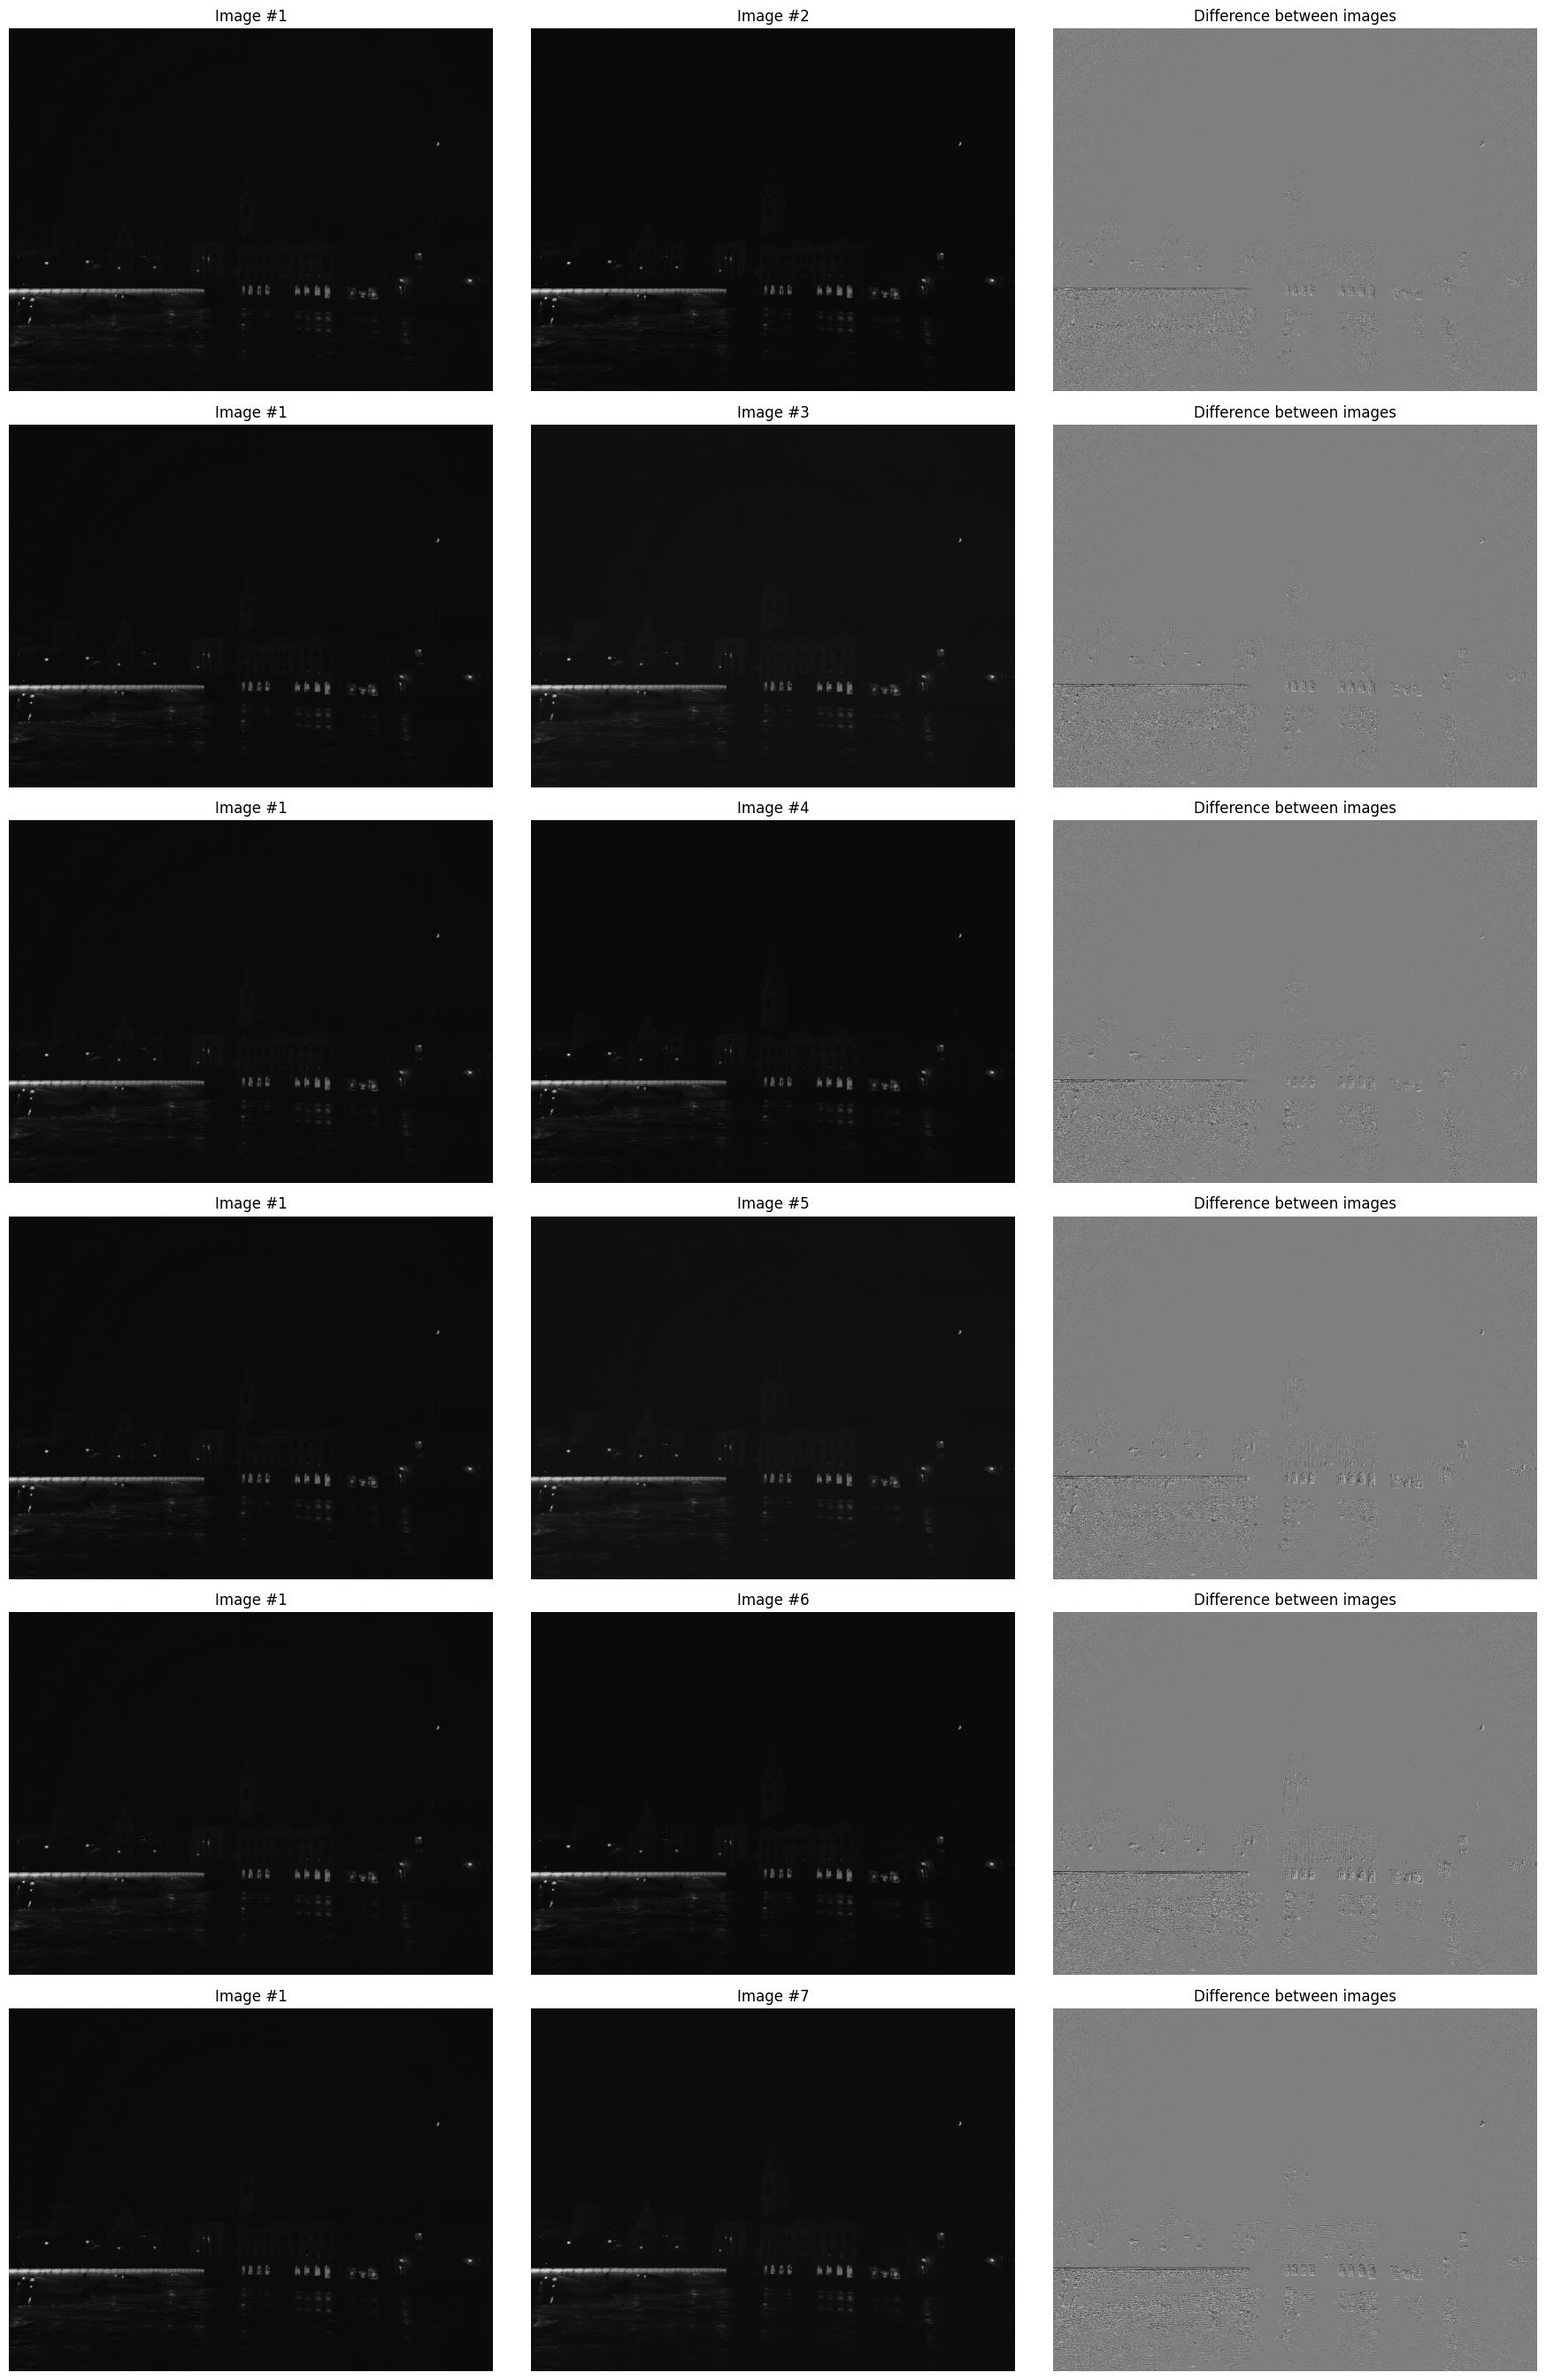

In [5]:
def laplacian_diff(image_1: np.ndarray, image_2: np.ndarray, scale: float = 10.0) -> np.ndarray:
    """
    Visualizes structural alignment errors between two grayscale images by comparing their high-pass (Laplacian) components.

    This method suppresses absolute brightness (DC component) and photon shot noise in highlights, focusing purely on edge displacement.

    Args:
        image_1 (numpy.ndarray): Reference image in range [0, 1].
            Has to be downsampled grayscale (not Bayer).
        image_2 (numpy.ndarray): Alternate image in range [0, 1] to compare.
        scale (float): Multiplier to amplify subtle edge misalignments.
            Defaults to 10.0.

    Returns:
        numpy.ndarray: A grayscale visualization where 0.5 (neutral gray)
            indicates perfect alignment, and bright/dark "double edges"
            indicate spatial shifts.

    """
    # High-pass filter (Laplacian)
    kernel = np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0],
    ])
    laplacian_1 = nd.convolve(image_1, kernel)
    laplacian_2 = nd.convolve(image_2, kernel)

    # 0.5 is "neutral gray"
    return np.clip(0.5 + (laplacian_1 - laplacian_2) * scale, 0, 1)


ref_image = processed_images[0]
ref_metadata = metadata[0]
ref_luma = get_luma_proxy(ref_image, ref_metadata)


best_nrow, best_ncol = find_best_layout((len(processed_images) - 1) * 3)
fig_size = find_best_figsize(processed_images, best_nrow, best_ncol)

_, axes = plt.subplots(best_nrow, best_ncol, figsize=fig_size)
# Turn off all axes in one go
for ax in axes.flat:
    ax.axis("off")
axes = axes.flat

for idx in range(1, len(processed_images)):
    ax = next(axes)
    ax.set_title("Image #1")
    ax.imshow(ref_image, cmap="grey")

    ax = next(axes)
    tgt_image = processed_images[idx]
    tgt_metadata = metadata[idx]
    ax.set_title(f"Image #{idx + 1}")
    ax.imshow(tgt_image, cmap="grey")

    ax = next(axes)
    tgt_luma = get_luma_proxy(tgt_image, tgt_metadata)
    ax.set_title("Difference between images")
    ax.imshow(laplacian_diff(ref_luma, tgt_luma), cmap="grey")

plt.tight_layout()

The visualization shows "double edges" where:

- Bright regions: Target image's edge is displaced rightward relative to reference
- Dark regions: Target image's edge is displaced leftward
- Neutral gray (0.5): Perfect alignment—no displacement detected
<div class="alert alert-block alert-info"><b>Key Insight</b>: Even small sub-pixel shifts (< 1 pixel) become visible in the Laplacian difference, allowing us to detect motion that would be invisible to the naked eye.</div>

The structural differences confirm genuine camera movement between frames.

## 3. Align & Merge

The Align & Merge pipeline performs block-based alignment of RAW images using a multi-level pyramid approach, then merges them using SNR-weighted averaging with temporal robustness. Key innovations include:

- **Lucky Imaging**: Selects the sharpest short-exposure frame as reference
- **Hierarchical Search**: Coarse-to-fine alignment across 3 pyramid levels (1/4, 1/2, full resolution)
- **VW-SAD Scoring**: Variance-weighted Sum of Absolute Differences for noise-normalized matching
- **Adaptive Robustness**: Dynamic weighting based on exposure time and image quality
- **Bayer-Safe Interpolation**: Color-preserving sub-pixel sampling that maintains CFA integrity

**Expected Performance**: For N frames with identical exposure, theoretical SNR gain is $\sqrt{N}$. 

In [6]:
isp_pipeline.steps = [ISPStep.ALIGN_AND_MERGE]
merged_image = isp_pipeline.run(processed_images, metadata)

2026-04-03 14:56:51.494 | INFO     | pipeline:run:78 - Executing step 1/1 `align_and_merge` 
2026-04-03 14:56:51.789 | INFO     | pipeline_steps.align_and_merge:find_sharpest_image_idx:175 - Lucky Imaging: Selected frame `1` (+5.4% sharper than short-exposure avg)
Align&Merge (Images): 100%|##########| 7/7 [00:03<00:00,  2.28it/s]
2026-04-03 14:56:54.915 | INFO     | pipeline:run:85 - Step 1/1 `align_and_merge` took 0:00:03.420531
2026-04-03 14:56:54.915 | INFO     | pipeline:run:101 - Full run took 0:00:03.420872


The images have been successfully aligned. The process was expedited by the use of Numba and parallelization, resulting in a relatively short duration. However, for production-grade pipelines, the time required would be significantly reduced.

It is important to note that this repository is intended for educational purposes, and therefore code readability is prioritized over speed. (In pure Python, this step would take several minutes, potentially exceeding ten.)

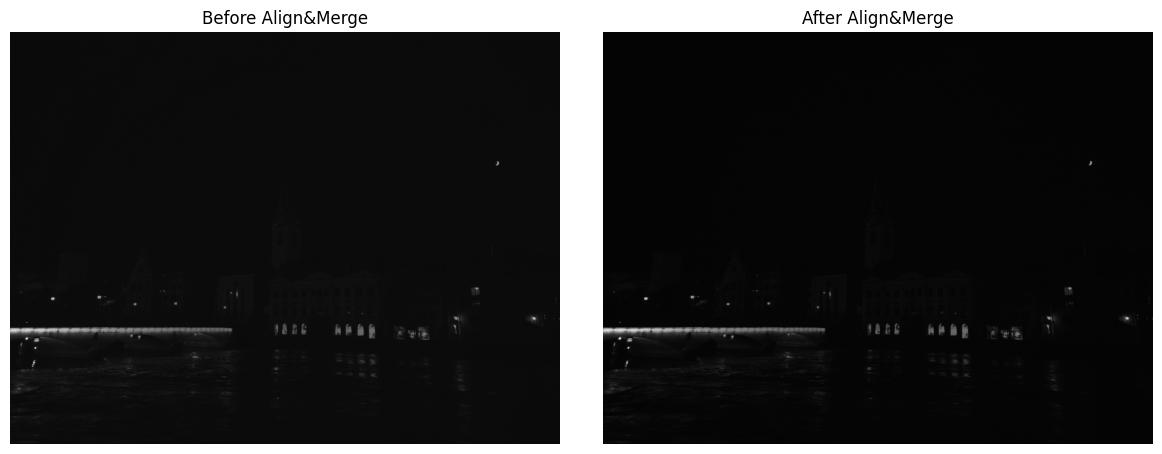

In [7]:
imgs = [processed_images[0], merged_image]
titles = ["Before Align&Merge", "After Align&Merge"]
plot_images(imgs, titles)

At this stage of the pipeline, images are still in linear space, which explains their low contrast. 

To enhance the viewing experience, images will be displayed in non-linear space with gamma correction applied.

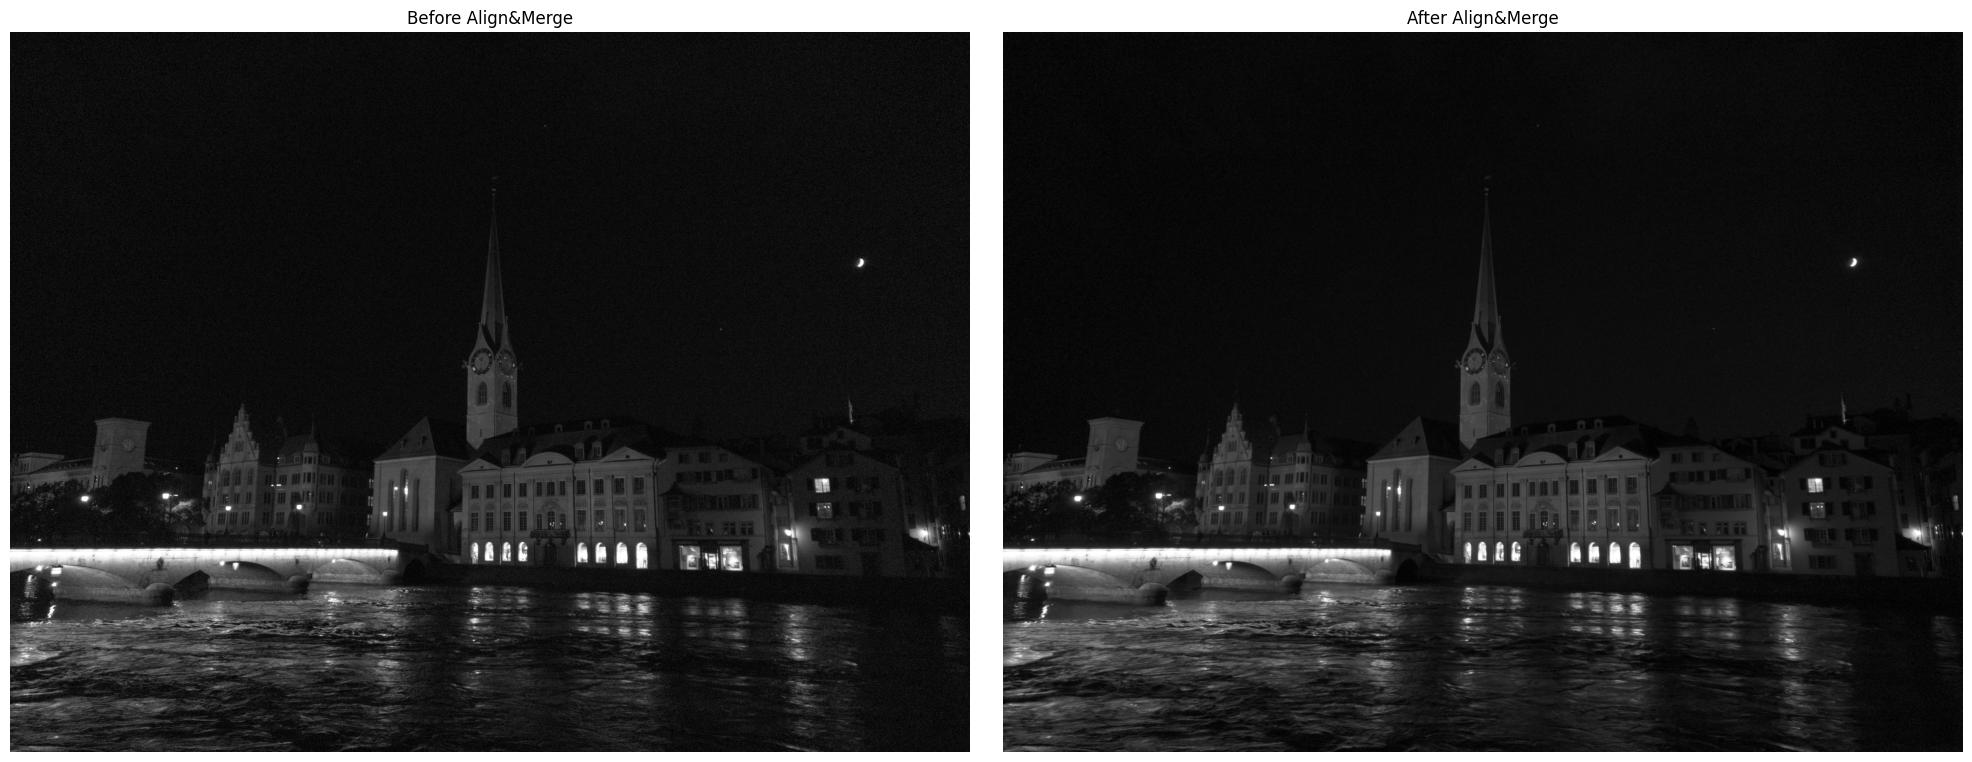

In [8]:
def apply_gamma(x: np.ndarray) -> np.ndarray:  # noqa: D103
    return x.clip(0, 1) ** (1 / 2.2)


imgs = [processed_images[0], merged_image]
imgs = [x.clip(0, 1) ** (1 / 2.2) for x in imgs]
titles = ["Before Align&Merge", "After Align&Merge"]
plot_images(imgs, titles, inch_width_per_image=10)

# 4. Comparing zoomed-in crops of images

Although the image on the right appears to be “clearer”, it is advisable to zoom in and examine it more closely.

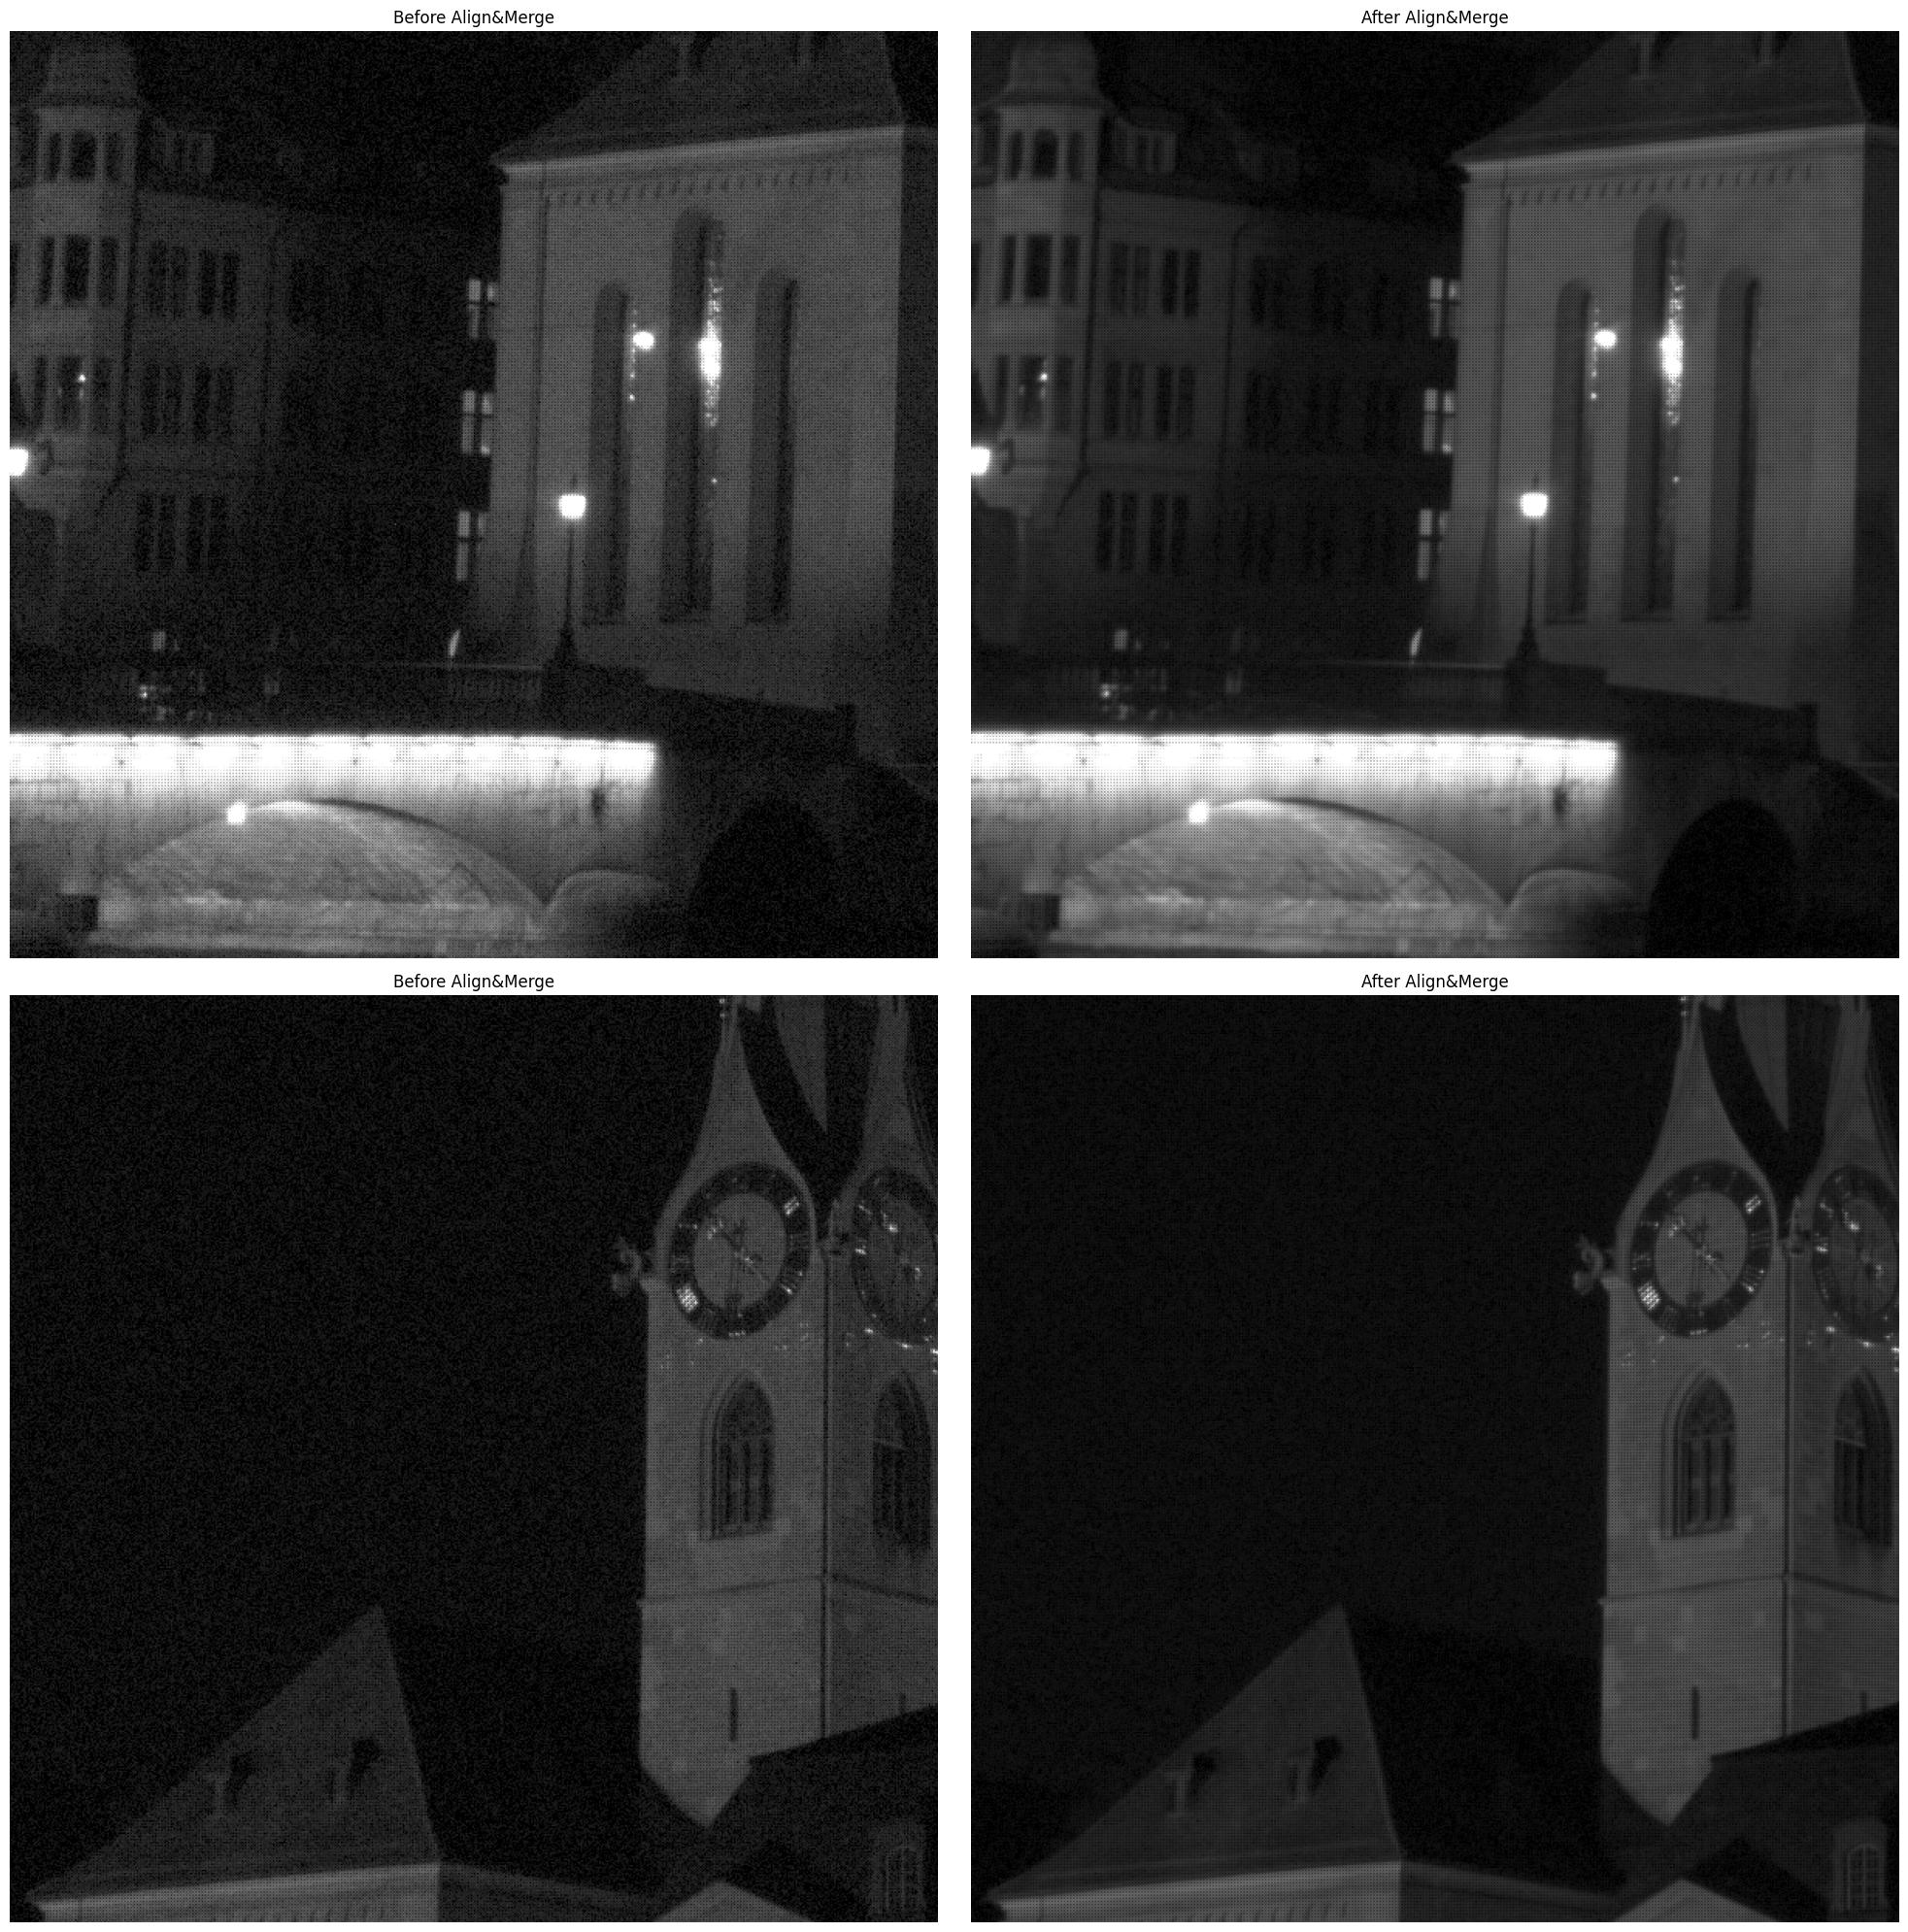

In [9]:
def get_crop(img: np.ndarray, window_size: int = 300, shift_y: int = 0, shift_x: int = 0) -> np.ndarray:  # noqa: D103
    center_x = img.shape[0] // 2
    center_y = img.shape[1] // 2
    return img[
        center_y - window_size + shift_y : center_y + window_size + shift_y,
        center_x - window_size + shift_x : center_x + window_size + shift_x,
    ]


window_size = 300
zoomed_in_imgs = [
    get_crop(imgs[0], window_size=window_size),
    get_crop(imgs[1], window_size=window_size),
    get_crop(imgs[0], window_size=window_size, shift_y=-500, shift_x=300),
    get_crop(imgs[1], window_size=window_size, shift_y=-500, shift_x=300),
]

plot_images(zoomed_in_imgs, titles * 2, max_per_row=2, inch_width_per_image=10)

The merged image has less noise because the noise is random. When multiple images are aligned and merged, the noise cancels out across frames, while image detail remains constant and is averaged.

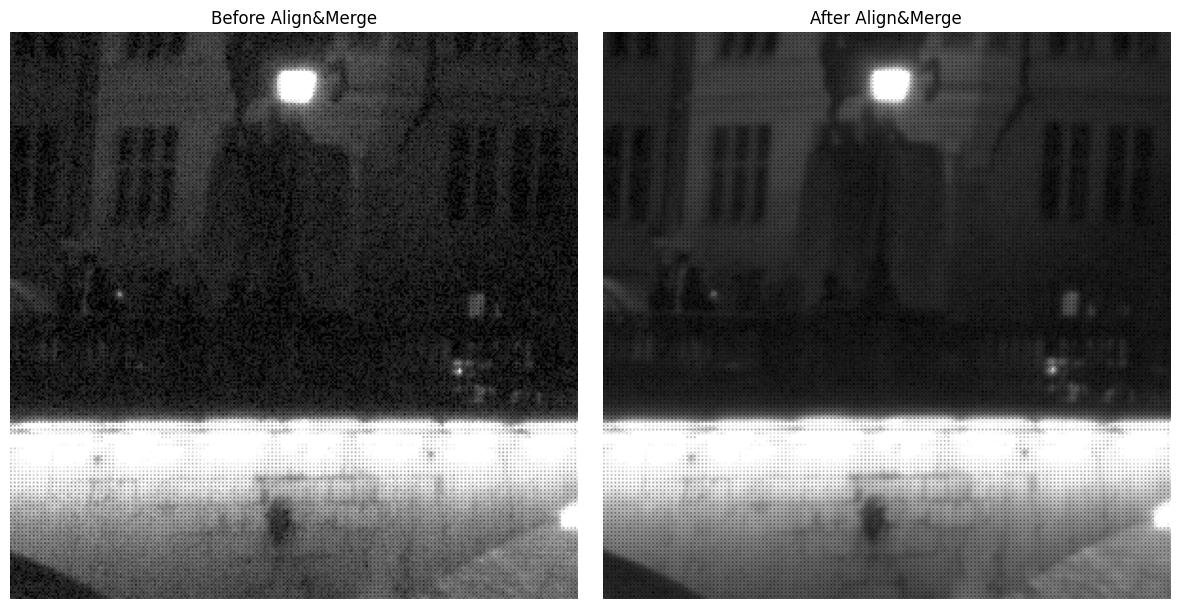

In [10]:
params = dict(window_size=150, shift_y=100, shift_x=-300)
zoomed_in_imgs = [
    get_crop(imgs[0], **params),
    get_crop(imgs[1], **params),
]

plot_images(zoomed_in_imgs, titles, max_per_row=2)

The side-by-side comparison reveals the power of temporal stacking:

**Before Align & Merge (Single Frame)**
- Visible sensor noise in dark regions
- Some detail loss due to shot noise
- Natural dynamic range limitations

**After Align & Merge (7-Frames Merged)**
- Dramatically reduced noise floor
- Sharper edges with better contrast
- Preserved fine details that were lost in single-frame averaging

<div class="alert alert-block alert-info"><b>Key Insight</b>: The merged image maintains spatial coherence while reducing random noise. This is the essence of "lucky imaging"-combining multiple exposures to achieve higher SNR than any individual frame.</div>

The result is an image that's not just "cleaner" but also retains more of the original scene's detail.

## 5. Calculating SNR

Now, let us precisely quantify the reduction in noise in the merged image by calculating the Signal-to-Noise Ratio.

We will select a uniform portion of the image, in our case, the sky, and perform the calculations.

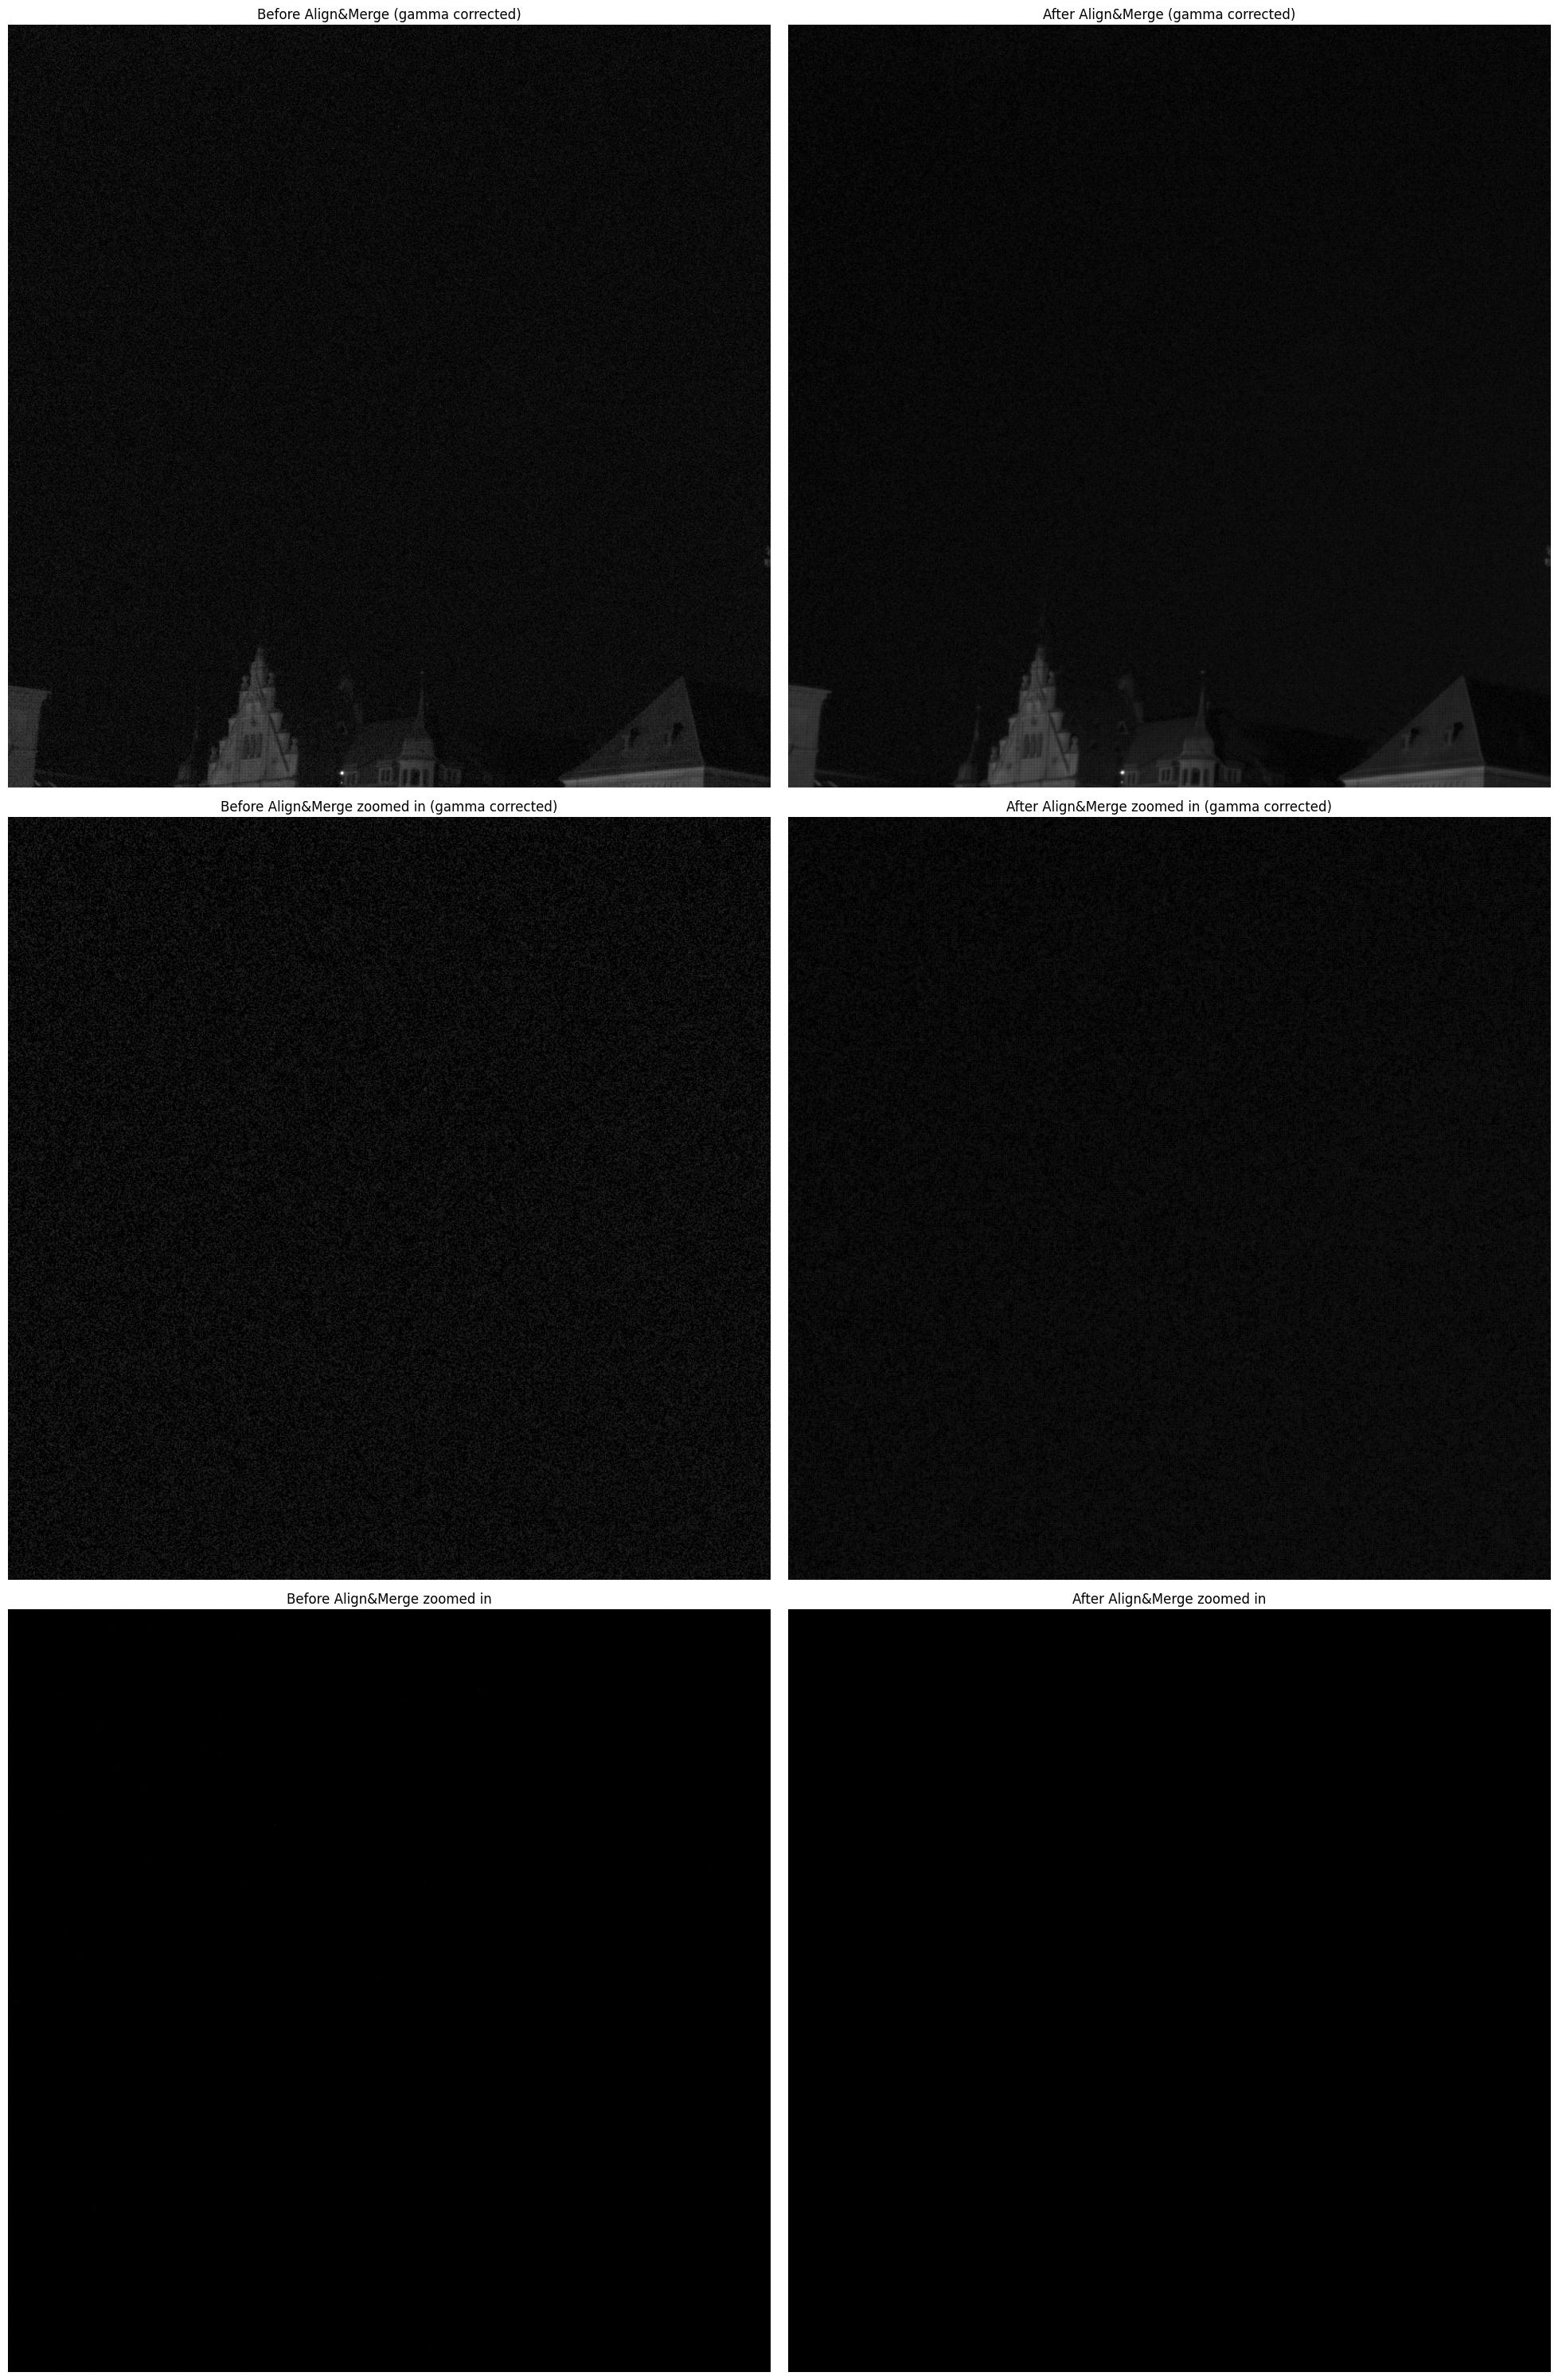

In [11]:
imgs = [processed_images[0], merged_image]

params = dict(window_size=350, shift_y=-900, shift_x=-300)
zoomed_in_imgs = [
    get_crop(apply_gamma(imgs[0]), **(params | dict(window_size=700))),
    get_crop(apply_gamma(imgs[1]), **(params | dict(window_size=700))),
    get_crop(apply_gamma(imgs[0]), **params),
    get_crop(apply_gamma(imgs[1]), **params),
    get_crop(imgs[0], **params),
    get_crop(imgs[1], **params),
]
titles = [
    "Before Align&Merge (gamma corrected)",
    "After Align&Merge (gamma corrected)",
    "Before Align&Merge zoomed in (gamma corrected)",
    "After Align&Merge zoomed in (gamma corrected)",
    "Before Align&Merge zoomed in",
    "After Align&Merge zoomed in",
]

plot_images(zoomed_in_imgs, titles, max_per_row=2, inch_width_per_image=10)

Calculation will be performed on non-gamma-corrected crops of images.

In [12]:
ref_crop, tgt_crop = zoomed_in_imgs[-2:]
print(f"Size of the patch: reference shape is {ref_crop.shape} | target shape is {tgt_crop.shape}")

ref_snr = ref_crop.mean() / ref_crop.std()
tgt_snr = tgt_crop.mean() / tgt_crop.std()

print(f"Signal-to-Noise ratio of the reference crop: {ref_snr:.4f}")
print(f"Signal-to-Noise ratio of the target crop: {tgt_snr:.4f}")
print(f"After merging SNR increase by a factor of {tgt_snr / ref_snr:.4f}")

Size of the patch: reference shape is (700, 700) | target shape is (700, 700)
Signal-to-Noise ratio of the reference crop: 0.2320
Signal-to-Noise ratio of the target crop: 0.7423
After merging SNR increase by a factor of 3.1994


In [13]:
np.sqrt(len(processed_images))

np.float64(2.6457513110645907)

The measured **3.19x** gain surpasses the theoretical **2.64x** limit because bilinear interpolation acts as a hidden spatial low-pass filter. 

When calculating a sub-pixel offset, the algorithm averages the four nearest neighboring pixels to determine the new value; this internal "mini-average" performs spatial denoising before the temporal merge even begins. In a dark sky patch, this effectively combines two noise-reduction strategies, resulting in a cleaner statistical profile than pure temporal stacking alone would provide.


However, this "bonus" SNR comes with a trade-off in **Modulation Transfer Function (MTF)**, or image sharpness. While the noise is smoothed out, the bilinear kernel also blurs fine, high-frequency details like distant stars or sensor textures. 

# Appendix: implementation explanation

<div class="alert alert-block alert-success">Since now we know what Align&Merge step produces, let's take a look at how it actually does it.</div>

Below one can find explanation of most important functions from [align_and_merge.py](src/pipeline_steps/align_and_merge.py).

# 1. The Luma Proxy

When aligning RAW images, we face a "phase" problem: a Bayer sensor doesn't have a single "brightness" value per pixel; it has a mosaic of Red, Green, and Blue. If the camera moves by exactly one pixel, a Red sensor is now looking at a Green patch, causing the SAD (Sum of Absolute Differences) to spike even if the image hasn't actually changed.

To solve this, we convert the Bayer RAW into a **Luma Proxy** at half-resolution.

### Why this approach?
* *Phase Invariance:* By collapsing a $2 \times 2$ Bayer quad into a single luma value, we ensure the alignment is based on structural brightness rather than color filter positions.
* *SNR Optimization:* We use a weighting of **70% Green** (split between Gr and Gb) and **15% each for Red and Blue**. Green pixels are more numerous and typically have the highest Signal-to-Noise Ratio, making them the most reliable anchors for motion estimation.
* *Computational Efficiency:* The "Reshape Trick" combined with `np.einsum` allows us to process millions of pixels using vectorized CPU instructions, avoiding slow Python loops.

Visualizing the Input RAW vs. Proxy

The RAW image is typically very dark (linear space) and looks "textured" due to the Bayer pattern. The Luma Proxy should look like a clean, albeit smaller, grayscale photograph.


Raw data shape: (10, 10) --> Luma Proxy shape: (5, 5)
RAW mean: 0.1985 | Proxy mean: 0.1958


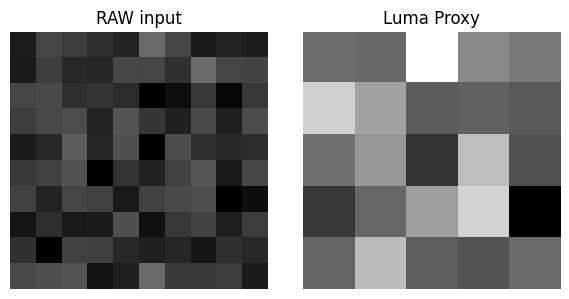

In [64]:
fake_raw = np.random.normal(loc=0.2, scale=0.1, size=(10, 10)).clip(0, 1).astype(np.float32)
fake_metadata = {"color_desc": "RGBG", "raw_pattern": [[0, 1], [3, 2]]}
# In our synthetic case, the formula is: (0.15*0) + (0.35*1) + (0.35*1) + (0.15*1) = 0.85
luma_proxy = get_luma_proxy(fake_raw, fake_metadata)

print(f"Raw data shape: {fake_raw.shape} --> Luma Proxy shape: {luma_proxy.shape}")
# Verification of Value Range
# If RAW mean is 0.2, and weights sum to 1.0 (0.15+0.35+0.35+0.15), the Proxy mean should also be approximately 0.2.
print(f"RAW mean: {fake_raw.mean():.4f} | Proxy mean: {luma_proxy.mean():.4f}")
plot_images((fake_raw, luma_proxy), ("RAW input", "Luma Proxy"), inch_width_per_image=3)

**Interpretation of Results**
* **Resolution:** Note that the output dimensions are exactly $(\frac{H}{2}, \frac{W}{2})$.
* **Demosaicing-free:** We have obtained a grayscale representation without performing expensive (and potentially artifact-prone) demosaicing.
* **Weights Check:** Even in areas with heavy Red or Blue saturation (like a red flower or blue sky), the $0.15$ weighting ensures we still have a valid signal for the alignment step to "grab" onto.

## 1.1. Hierarchical Search via Image Pyramids

To understand how `downsample_luma_proxy` fits into the overall pipeline, we have to look at the **Hierarchical Search** strategy. In high-resolution photography, camera shake can shift an image by 50 or 100 pixels. Searching for such a large displacement at full resolution is like trying to find a specific grain of sand on a beach - it is computationally expensive and easy to get "lost" in the local noise.

The Strategy: **Coarse-to-Fine**

Hierarchical search solves this by creating an **Image Pyramid**, where each level is a lower resolution version of the one below it. The process works in three distinct phases:

1.  **Level 2 (Coarse):** We use the output of `downsample_luma_proxy` applied twice. At this $1/4$ scale, a massive 32-pixel shift in the original image is reduced to a tiny 8-pixel shift. We perform a global search here to find the "big" movement.
2.  **Level 1 (Intermediate):** We take the coarse offset from Level 2 and "upres" it to act as a starting hint. We then perform a very small local search (e.g., $\pm 1$ pixel) to refine the position.
3.  **Level 0 (Fine):** We repeat the refinement at full resolution using the original luma proxy. This gives us the final, high-precision integer alignment.

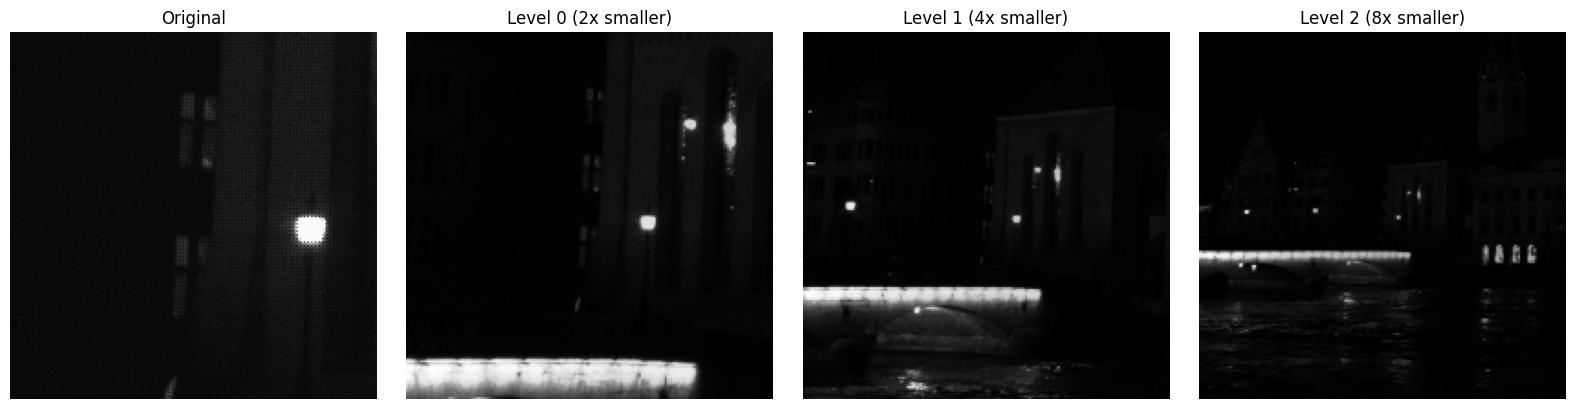

In [77]:
high_res_img = processed_images[0]
level_0 = get_luma_proxy(high_res_img, metadata[0])
level_1 = downsample_luma_proxy(level_0)
level_2 = downsample_luma_proxy(level_1)

params = dict(window_size=100)
high_res_crop = get_crop(high_res_img, **params)
level_0_crop = get_crop(level_0, **params)
level_1_crop = get_crop(level_1, **params)
level_2_crop = get_crop(level_2, **params)

plot_images(
    (high_res_crop, level_0_crop, level_1_crop, level_2_crop),
    ("Original", "Level 0 (2x smaller)", "Level 1 (4x smaller)", "Level 2 (8x smaller)"),
    inch_width_per_image=4,
    max_per_row=4,
)

del level_0, level_1, level_2
del level_0_crop, level_1_crop, level_2_crop

The `downsample_luma_proxy` function isn't just about making the image smaller; it's about **Information Density** and **SNR (Signal-to-Noise Ratio)**. 

By averaging $2 \times 2$ blocks of pixels, the function acts as a **Low-Pass Filter**. This suppresses the high-frequency "salt and pepper" sensor noise that is rampant in RAW data. Without this smoothing, the alignment algorithm might accidentally align two random noise patterns instead of the actual image structure. Furthermore, a $32 \times 32$ tile at the coarsest level covers a much larger physical area of the scene (effectively $128 \times 128$ in the original). This provides the "big picture" context-like edges of buildings or horizons - needed to anchor the alignment before the finer levels handle the microscopic details.


# 2. Image Noise Profile

**Why do we need a Noise Profile?**

The noise profile is the "intelligence" behind the alignment and merging stages. In a RAW burst, every pixel contains a mix of actual scene information and random sensor fluctuations. Without a noise model, the algorithm cannot distinguish between a **moving object** (which should be rejected to avoid ghosting) and **random noise** (which should be averaged to improve SNR).

In the **Alignment** phase, we use the noise profile to normalize the Sum of Absolute Differences (SAD). Instead of looking at the raw difference between two tiles, we look at the difference relative to the expected noise variance ($\sigma^2$). 

This ensures that:
* In **bright areas**, where shot noise is high, the algorithm is more "forgiving" of larger absolute differences.
* In **dark areas**, where noise should be low, even a small difference is flagged as a potential alignment error.

</br>

**Metadata vs. Estimation**

Most professional RAW formats (like DNG) include a `NoiseProfile` tag in their metadata. This tag typically contains pairs of values for each color channel representing the **Shot Noise** (gain-dependent) and **Read Noise** (fixed) parameters calibrated by the manufacturer for that specific sensor and ISO setting.

However, if this metadata is missing, which can happen with custom sensor rigs, specific mobile captures, or corrupted files - the ISP must "self-calibrate." The `estimate_noise_profile` function serves as this fail-safe. It analyzes the image itself to reverse-engineer the sensor's behavior, ensuring the rest of the pipeline (alignment and robust merging) has the statistical parameters it needs to function correctly.


</br>

**The Mathematical Model: PTC Analysis**

The function estimates noise using **Photon Transfer Curve (PTC)** analysis. In a CMOS sensor, the total noise variance ($\sigma^2$) is modeled as a linear function of the signal mean ($S$):

$$\sigma^2 = g \cdot S + \sigma_{read}^2$$

1.  **Shot Noise:** Caused by the discrete nature of photons. It follows a Poisson distribution where variance is proportional to the signal mean ($S$).
2.  **Read Noise:** Electronic noise independent of the light level, acting as a constant baseline ($\sigma_{read}^2$).

</br>

**The "Flat Patch" Challenge**

A major hurdle in estimating noise from a single image is **texture**. If a patch contains an edge or a fine pattern, the calculated variance will be high due to the image content, not the sensor noise. 
To solve this, your function:
* **Bins by Brightness:** Ensures we sample the relationship across the entire dynamic range.
* **The 10th Percentile Filter:** By selecting only the lowest variance patches in each brightness bin, we effectively discard any patches containing edges or textures, leaving only "flat" areas where the variance is purely stochastic (noise).

In [ ]:
shot_noise, read_noise = estimate_noise_profile(processed_images[0])
print(f"Shot noise:\n {shot_noise}")
print(f"Read noise:\n {shot_noise}")

Shot noise:
 [[0.00195354 0.00191683]
 [0.00164773 0.00199704]]
Read noise:
 [[0.00195354 0.00191683]
 [0.00164773 0.00199704]]


These two $2 \times 2$ arrays represent the **physical fingerprint** of the camera sensor at the moment the photo was taken. Each position in the grid corresponds to one of the four colors in the Bayer mosaic (typically R, Gr, Gb, B).

**The First Array: Shot Noise (Slope $g$)**

Values: $\approx 0.0019$

This represents the *System Gain*. Because light is made of discrete photons (Poisson distribution), the noise variance increases as the image gets brighter. 
* Interpretation: For every unit of light (signal) you capture, you are adding roughly $0.2\%$ of that value as noise variance.
* Why they differ: The values aren't identical (e.g., $0.0016$ vs $0.0019$). This is normal; different color filters (Red vs. Blue) have different sensitivities and quantum efficiencies, meaning they "feel" shot noise differently.

**The Second Array: Read Noise (Intercept $\sigma_{read}^2$)**

Values: $\approx 1.0 \times 10^{-5}$ ($0.00001$)

This is the *Noise Floor*. This is the electronic noise generated by the sensor's circuitry even if the lens cap was on and no light hit the sensor.
* Interpretation: This is the baseline uncertainty. Even in total darkness, pixel values will fluctuate by roughly $\pm \sqrt{10^{-5}} \approx 0.003$ on a $[0, 1]$ scale.
* Stability: These values are much more consistent across the grid than the shot noise. Read noise is usually a property of the sensor's readout electronics, which are shared across the channels.

**How the Pipeline Uses These**

When `Align & Merge` code calculates the difference (SAD) between two frames, it uses these numbers to decide if a difference is "real."

For a pixel with brightness $S$, the expected noise is:
$$\sigma^2 = (Slope \cdot S) + Intercept$$

If the difference between two frames is much larger than this $\sigma^2$, the algorithm assumes **motion (ghosting)** and rejects the pixel. If the difference is within this $\sigma^2$, it assumes it’s just **sensor noise** and merges them to create a cleaner image.

> It's very "healthy" profile here. The read noise is quite low (5 decimal places), and the shot noise slope is consistent with a modern CMOS sensor at a moderate ISO.